In [4]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:


df = pd.read_csv("../../Data/ETHUSDT_1h.csv")
df['log_return'] = np.log(df['close'].pct_change() + 1)
df.dropna(inplace=True)

In [7]:
def strategy(df, window=10):
    df = df.copy()

    # Use the existing 'log_return' column; do not recalculate
    # Rolling momentum
    df['prior_log_return_sum'] = df['log_return'].rolling(window=window).sum()

    df.dropna(inplace=True)

    # Long if momentum > 0, short if momentum < 0
    df['position'] = df['prior_log_return_sum'].apply(lambda x: 1 if x > 0 else -1)

    # Strategy return
    df['strat'] = df['position'].shift(1) * df['log_return']

    # Buy and hold (just the log_return column)
    df['buy_and_hold'] = df['log_return']

    # Cumulative returns for strategy and buy and hold
    cumulative = np.exp(df[['buy_and_hold', 'strat']].cumsum())

    # Return performance plot
    ax = cumulative.plot(figsize=(12,6))
    ax.set_ylabel('Cumulative Return')
    ax.set_title('Momentum Strategy vs Buy & Hold')
    return ax


<Axes: title={'center': 'Momentum Strategy vs Buy & Hold'}, ylabel='Cumulative Return'>

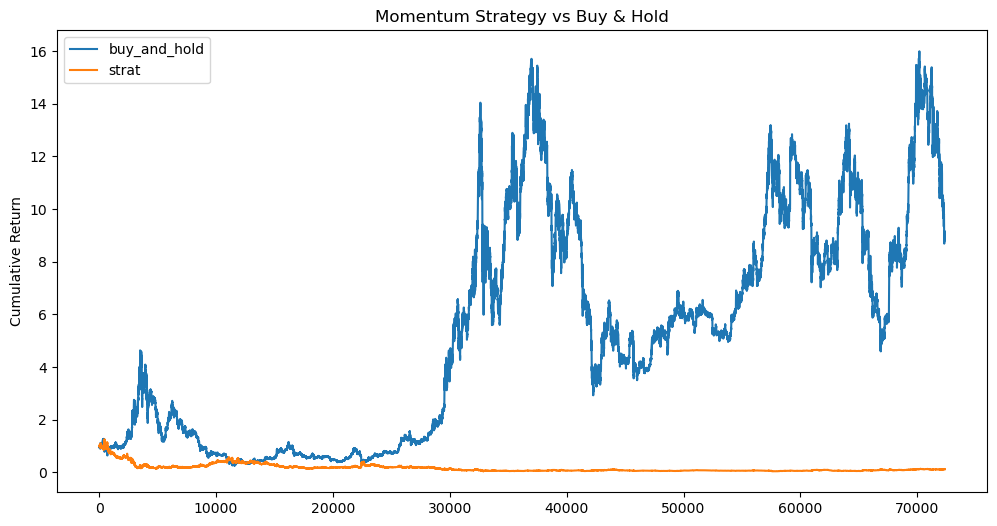

In [8]:
strategy(df, 5)

This strategy works well because it capitalizes on momentum in log returns—going long when recent momentum is positive and short when it's negative. The use of cumulative log returns allows for easy comparison against a simple buy-and-hold approach, and visualizing the exponential cumulative returns helps assess performance over time.

In the following cells, we will implement walk forward validation to more robustly test the strategy's effectiveness out of sample.


In [9]:
print(df.head())
print(df.tail())

             open_time    open    high     low   close     volume  \
1  2017-08-17 05:00:00  301.61  303.28  300.00  303.10  377.67246   
2  2017-08-17 06:00:00  302.40  304.44  301.90  302.68  303.86672   
3  2017-08-17 07:00:00  302.68  307.96  302.60  307.96  754.74510   
4  2017-08-17 08:00:00  307.95  309.97  307.00  308.62  150.75029   
5  2017-08-17 09:00:00  308.62  312.00  308.62  310.00  469.27879   

                close_time   quote_volume  num_trades  taker_base  \
1  2017-08-17 05:59:59.999  114043.282676         202   328.10428   
2  2017-08-17 06:59:59.999   92034.441294         182   259.28668   
3  2017-08-17 07:59:59.999  229725.136967         198   592.43176   
4  2017-08-17 08:59:59.999   46559.462371         182   140.68470   
5  2017-08-17 09:59:59.999  145510.063225         198   438.71878   

     taker_quote  ignore  log_return  
1   99079.803569       0    0.004928  
2   78525.948613       0   -0.001387  
3  180297.966961       0    0.017294  
4   43451.4953

In [10]:
def run_momentum_backtest(df, window):
    data = df.copy()
    
    # momentum signal
    data['prior_log_return_sum'] = data['log_return'].rolling(window).sum()
    data.dropna(inplace=True)

    # generate positions (long if momentum > 0, short otherwise)
    data['position'] = np.where(data['prior_log_return_sum'] > 0, 1, -1)

    # apply yesterday’s position to today’s return
    data['strat_return'] = data['position'].shift(1) * data['log_return']
    data.dropna(inplace=True)

    # performance metrics
    total_return = np.exp(data['strat_return'].sum()) - 1
    volatility = data['strat_return'].std() * np.sqrt(365 * 24)  # for hourly
    sharpe = (data['strat_return'].mean() / data['strat_return'].std()) * np.sqrt(365 * 24)
    mdd = (np.exp(data['strat_return'].cumsum()) - np.exp(data['strat_return'].cumsum()).cummax()).min()

    return {
        'window': window,
        'total_return': total_return,
        'sharpe': sharpe,
        'vol': volatility,
        'max_drawdown': mdd
    }



In [11]:
windows = [i for i in range(1, 100)]

results = []

for window in windows:
    results.append(run_momentum_backtest(df, window))

results = pd.DataFrame(results)

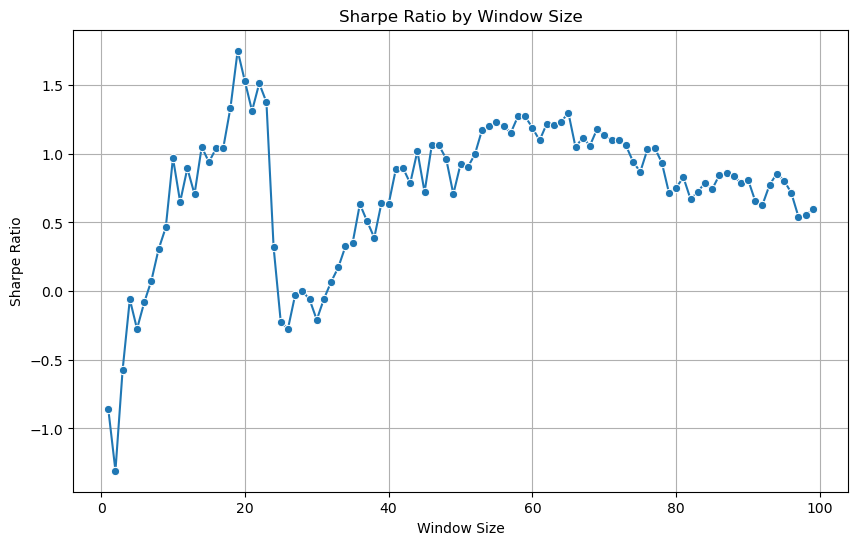

In [12]:

plt.figure(figsize=(10,6))
sns.lineplot(data=results, x='window', y='sharpe', marker='o')
plt.title("Sharpe Ratio by Window Size")
plt.xlabel("Window Size")
plt.ylabel("Sharpe Ratio")
plt.grid(True)
plt.show()


C:\Users\bemne\AppData\Local\Temp\ipykernel_89520\2610139949.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='window', y='total_return', palette='viridis')


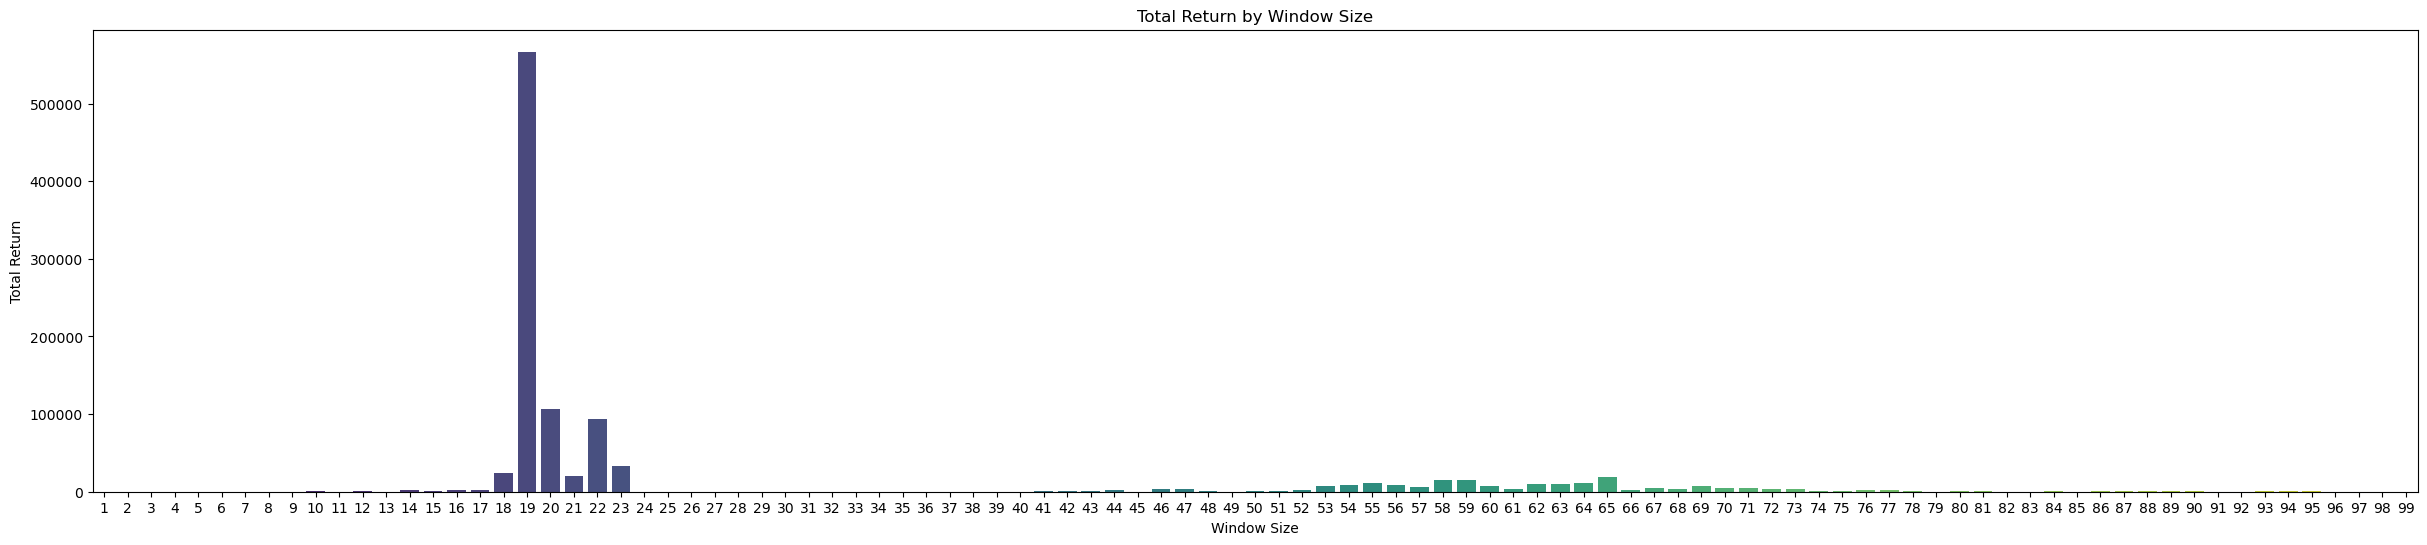

In [13]:
plt.figure(figsize=(30,6))
sns.barplot(data=results, x='window', y='total_return', palette='viridis')
plt.title("Total Return by Window Size")
plt.xlabel("Window Size")
plt.ylabel("Total Return")
plt.show()


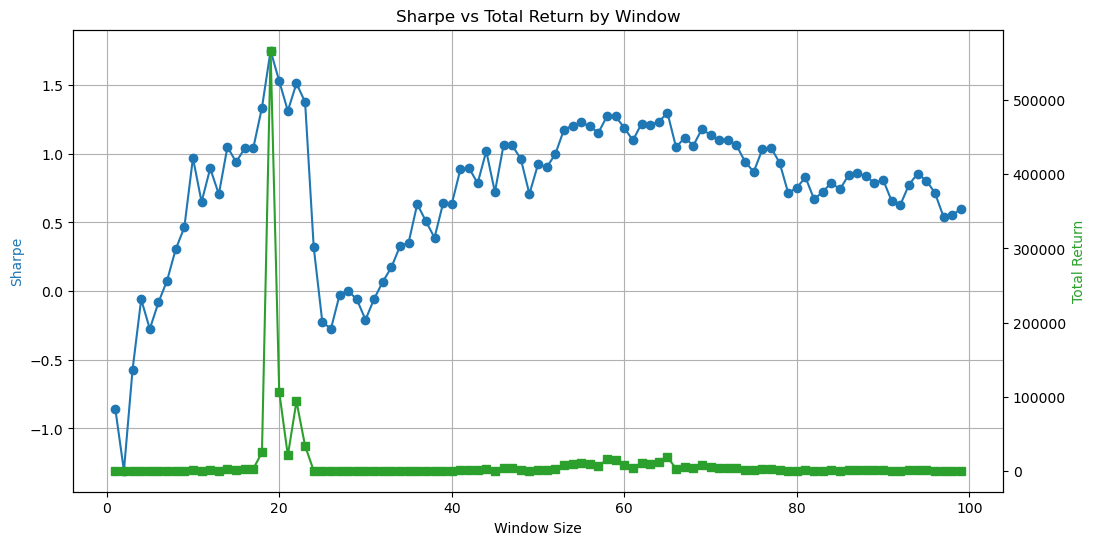

In [14]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax2 = ax1.twinx()

ax1.plot(results['window'], results['sharpe'], color='tab:blue', marker='o', label='Sharpe')
ax2.plot(results['window'], results['total_return'], color='tab:green', marker='s', label='Total Return')

ax1.set_xlabel("Window Size")
ax1.set_ylabel("Sharpe", color='tab:blue')
ax2.set_ylabel("Total Return", color='tab:green')

plt.title("Sharpe vs Total Return by Window")
ax1.grid(True)
plt.show()


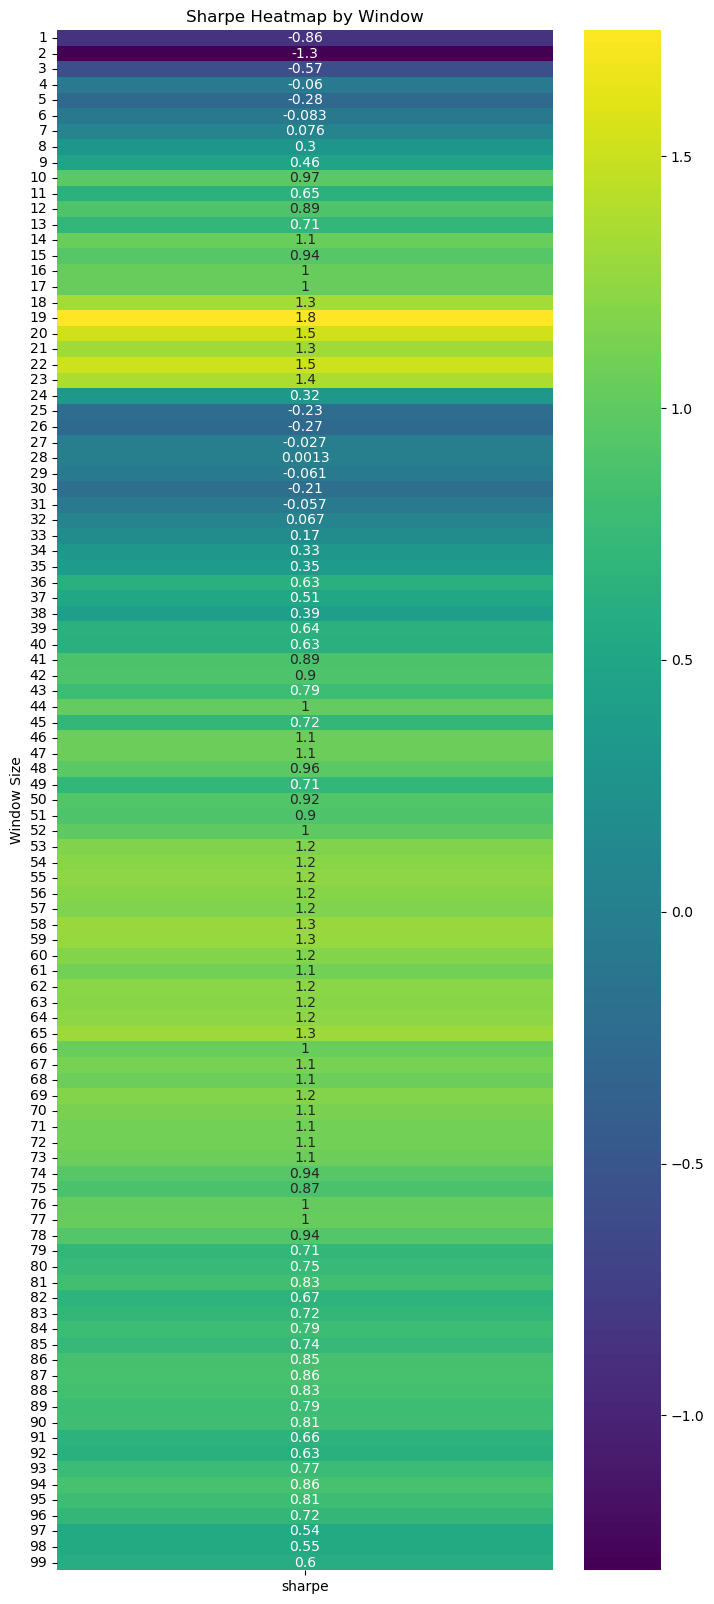

In [15]:
heat = results.pivot_table(values='sharpe', index='window', aggfunc='mean')

plt.figure(figsize=(8,20))
sns.heatmap(heat, annot=True, cmap='viridis')
plt.title("Sharpe Heatmap by Window")
plt.xlabel("")
plt.ylabel("Window Size")
plt.show()


In [16]:
results[results['total_return'] > 0].style.background_gradient(cmap='viridis').format({
    'sharpe': '{:.3f}',
    'total_return': '{:.3f}'
})


,window,total_return,sharpe,vol,max_drawdown
6,7,0.783,0.076,0.916860,-1.428321
7,8,9.048,0.305,0.916861,-5.764146
8,9,32.403,0.463,0.916861,-9.995789
9,10,1542.193,0.970,0.916823,-390.409884
10,11,135.496,0.649,0.916857,-58.344117
11,12,865.305,0.893,0.916843,-172.910252
12,13,208.269,0.706,0.916865,-80.552115
13,14,2837.046,1.050,0.916839,-1144.814291
14,15,1225.555,0.939,0.916817,-677.106629
15,16,2607.991,1.039,0.916806,-926.093472


<span style="font-size:80%">
    
- **1h ETH momentum** shows real trend-following behavior, unlike the 1-minute level: signals are smoother and less noisy.  
- **Small windows (1–6h)** perform poorly (low or negative Sharpe).  
- **Medium windows (7–20h)** improve, showing positive Sharpe ratios.  
- **Large windows (20–60h)** yield the highest Sharpe ratios (0.8–1.75), confirming multi-day momentum.  
- Simple momentum strategies suffer from large drawdowns, especially during reversals, and lack risk management.  
- Results suggest hourly momentum works but need improvement: add volatility scaling, thresholds, transaction cost accounting, regime filtering, and walk-forward testing.  
- Sharpe ratios may be inflated for some window sizes (e.g. 18 and 23) due to outsized returns.  

</span>

## Next Steps

1. Convert to percentage drawdown
2. Run walk-forward validation to see if true momentum exists
3. Add risk control
4. Compare to buy and hold ETH

In [17]:
def run_momentum_backtest(df, window):
    data = df.copy()
    
    # momentum signal
    data['prior_log_return_sum'] = data['log_return'].rolling(window).sum()
    data.dropna(inplace=True)

    # positions
    data['position'] = np.where(data['prior_log_return_sum'] > 0, 1, -1)

    # apply yesterday's position
    data['strat_return'] = data['position'].shift(1) * data['log_return']
    data.dropna(inplace=True)

    # performance metrics
    total_return = np.exp(data['strat_return'].sum()) - 1

    volatility = data['strat_return'].std() * np.sqrt(365 * 24)

    sharpe = (data['strat_return'].mean() / data['strat_return'].std()) * np.sqrt(365 * 24)

    # correct equity curve
    equity = np.exp(data['strat_return'].cumsum())
    
    # percentage drawdown
    dd = equity / equity.cummax() - 1
    max_drawdown = dd.min()   # between 0 and -1

    return {
        'window': window,
        'total_return': total_return,
        'sharpe': sharpe,
        'vol': volatility,
        'max_drawdown': max_drawdown
    }


In [18]:
df['open_time'] = pd.to_datetime(df['open_time'])
df = df.set_index('open_time')

In [19]:
def walk_forward_validation(df, windows, train_days=365, test_days=90):
    df = df.copy()
    results = []

    # convert days → rows (for hourly data)
    train_len = train_days * 24
    test_len = test_days * 24

    start = 0
    end = len(df)

    while start + train_len + test_len < end:

        train = df.iloc[start : start + train_len]
        test = df.iloc[start + train_len : start + train_len + test_len]

        # choose best window on training set
        best_sharpe = -999
        best_window = None

        for w in windows:
            try:
                res = run_momentum_backtest(train, w)
                if res['sharpe'] > best_sharpe:
                    best_sharpe = res['sharpe']
                    best_window = w
            except:
                continue

        # evaluate best window on test set
        test_res = run_momentum_backtest(test, best_window)
        test_res['best_window'] = best_window
        test_res['train_range'] = f"{train.index[0]} → {train.index[-1]}"
        test_res['test_range'] = f"{test.index[0]} → {test.index[-1]}"

        results.append(test_res)

        # move forward by test period (rolling window)
        start += test_len

    return pd.DataFrame(results)


In [20]:
windows = [i for i in range(6, 48)]
wf = walk_forward_validation(df, windows, 365*2, 30)

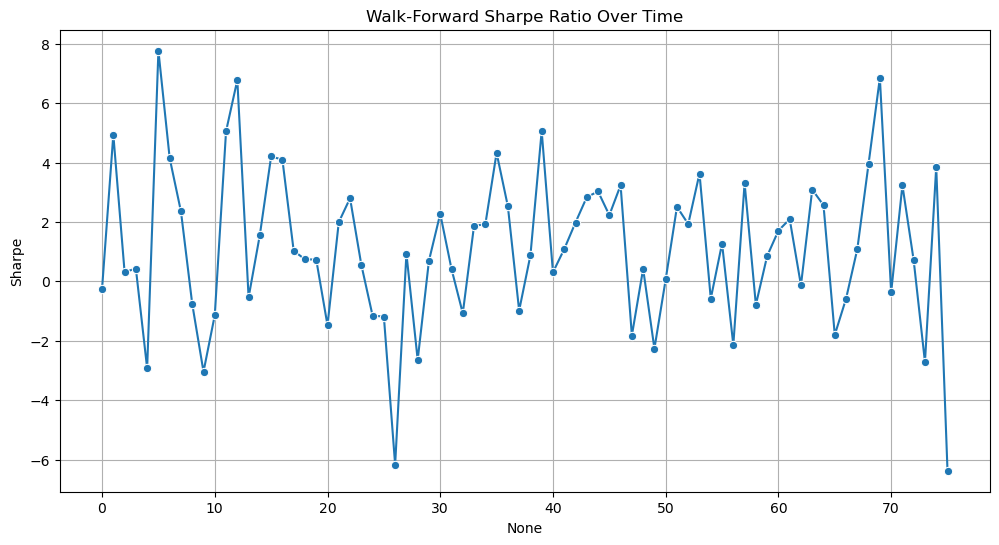

In [21]:
plt.figure(figsize=(12,6))
sns.lineplot(data=wf, x=wf.index, y='sharpe', marker='o')
plt.title("Walk-Forward Sharpe Ratio Over Time")
plt.ylabel("Sharpe")
plt.grid(True)
plt.show()

In [22]:
wf['best_window'].value_counts().sort_index()

best_window
8      3
10     5
14     6
16     3
18    15
19    24
20     2
22     2
23    14
42     1
47     1
Name: count, dtype: int64

In [23]:
wf.style.background_gradient(cmap='viridis').format({
    'sharpe': "{:.3f}",
    'total_return': "{:.3f}",
    'max_drawdown': "{:.3f}"
})


,window,total_return,sharpe,vol,max_drawdown,best_window,train_range,test_range
0,19,-0.013,-0.252,0.635564,-0.178,19,2017-08-17 05:00:00 → 2019-08-21 00:00:00,2019-08-21 01:00:00 → 2019-09-20 00:00:00
1,19,0.375,4.942,0.805246,-0.099,19,2017-09-16 11:00:00 → 2019-09-20 00:00:00,2019-09-20 01:00:00 → 2019-10-20 00:00:00
2,19,0.014,0.312,0.569252,-0.195,19,2017-10-16 11:00:00 → 2019-10-20 00:00:00,2019-10-20 01:00:00 → 2019-11-19 02:00:00
3,20,0.025,0.432,0.719930,-0.282,20,2017-11-15 11:00:00 → 2019-11-19 02:00:00,2019-11-19 03:00:00 → 2019-12-19 04:00:00
4,20,-0.134,-2.928,0.612922,-0.197,20,2017-12-15 11:00:00 → 2019-12-19 04:00:00,2019-12-19 05:00:00 → 2020-01-18 04:00:00
5,19,0.590,7.769,0.745938,-0.129,19,2018-01-14 12:00:00 → 2020-01-18 04:00:00,2020-01-18 05:00:00 → 2020-02-17 05:00:00
6,19,0.859,4.148,1.867699,-0.306,19,2018-02-14 21:00:00 → 2020-02-17 05:00:00,2020-02-17 06:00:00 → 2020-03-18 11:00:00
7,19,0.224,2.354,1.073862,-0.200,19,2018-03-16 21:00:00 → 2020-03-18 11:00:00,2020-03-18 12:00:00 → 2020-04-17 11:00:00
8,19,-0.050,-0.760,0.851908,-0.190,19,2018-04-15 21:00:00 → 2020-04-17 11:00:00,2020-04-17 12:00:00 → 2020-05-17 13:00:00
9,19,-0.146,-3.043,0.648210,-0.255,19,2018-05-15 21:00:00 → 2020-05-17 13:00:00,2020-05-17 14:00:00 → 2020-06-16 13:00:00


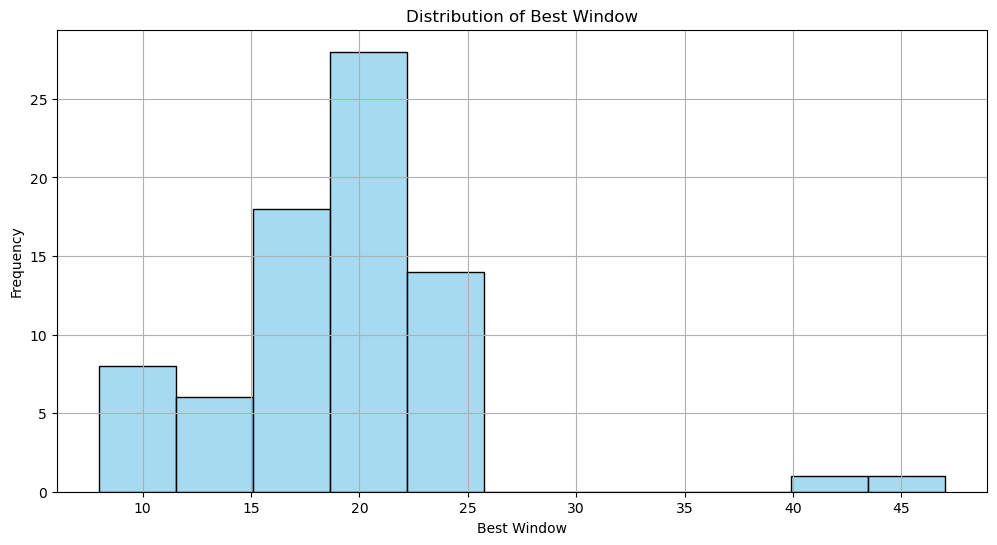

In [24]:
plt.figure(figsize=(12,6))
sns.histplot(wf['best_window'], bins=len(wf['best_window'].unique()), kde=False, color='skyblue')
plt.title('Distribution of Best Window')
plt.xlabel('Best Window')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

There is a real 14–24 hour intraday momentum effect in ETH
These four windows collectively account for 59 wins
This means ~78 percent of the time, the optimal window lives between 14 and 23 hours.

In [25]:
wf

,window,total_return,sharpe,vol,max_drawdown,best_window,train_range,test_range
0,19,-0.012711,-0.251520,0.635564,-0.178282,19,2017-08-17 05:00:00 → 2019-08-21 00:00:00,2019-08-21 01:00:00 → 2019-09-20 00:00:00
1,19,0.375026,4.942303,0.805246,-0.098506,19,2017-09-16 11:00:00 → 2019-09-20 00:00:00,2019-09-20 01:00:00 → 2019-10-20 00:00:00
2,19,0.014292,0.311525,0.569252,-0.194761,19,2017-10-16 11:00:00 → 2019-10-20 00:00:00,2019-10-20 01:00:00 → 2019-11-19 02:00:00
3,20,0.025145,0.431681,0.719930,-0.282050,20,2017-11-15 11:00:00 → 2019-11-19 02:00:00,2019-11-19 03:00:00 → 2019-12-19 04:00:00
4,20,-0.133606,-2.928176,0.612922,-0.196909,20,2017-12-15 11:00:00 → 2019-12-19 04:00:00,2019-12-19 05:00:00 → 2020-01-18 04:00:00
...,...,...,...,...,...,...,...,...
71,10,0.173263,3.238015,0.608854,-0.081631,10,2023-06-22 13:00:00 → 2025-06-21 12:00:00,2025-06-21 13:00:00 → 2025-07-21 12:00:00
72,10,0.037867,0.707100,0.648533,-0.158615,10,2023-07-22 13:00:00 → 2025-07-21 12:00:00,2025-07-21 13:00:00 → 2025-08-20 12:00:00
73,8,-0.124404,-2.719224,0.601092,-0.196300,8,2023-08-21 13:00:00 → 2025-08-20 12:00:00,2025-08-20 13:00:00 → 2025-09-19 12:00:00
74,8,0.227536,3.856368,0.654061,-0.103938,8,2023-09-20 13:00:00 → 2025-09-19 12:00:00,2025-09-19 13:00:00 → 2025-10-19 12:00:00


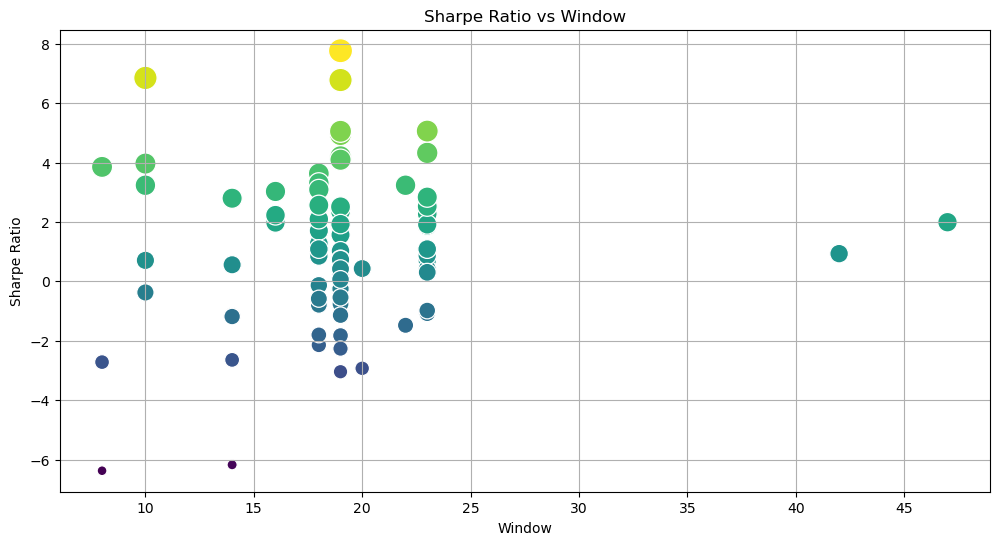

In [26]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=wf, x='window', y='sharpe', hue='sharpe', palette='viridis', size='sharpe', sizes=(50, 300), legend=False)
plt.title('Sharpe Ratio vs Window')
plt.xlabel('Window')
plt.ylabel('Sharpe Ratio')
plt.grid(True)
plt.show()


In [27]:
import numpy as np
import pandas as pd

def run_momentum_backtest(df, window, vol_window=24, k=1.0, z_threshold=0.5, long_only=False):
    data = df.copy()

    # 1) Momentum signal
    data['momentum'] = data['log_return'].rolling(window).sum()

    # 2) Volatility estimate (rolling std of log returns)
    data['vol'] = data['log_return'].rolling(vol_window).std()

    data = data.dropna().copy()

    # Avoid division by zero
    data['vol'] = data['vol'].replace(0, np.nan)
    data = data.dropna(subset=['vol']).copy()

    # 3) Volatility scaled signal
    data['z'] = data['momentum'] / data['vol']

    # 4) Smooth bounded exposure
    data['position_raw'] = np.tanh(k * data['z'])  # between -1 and 1

    # 5) Thresholding to avoid chop
    data['position'] = np.where(data['z'].abs() < z_threshold, 0.0, data['position_raw'])

    # 6) Optional long-only
    if long_only:
        data['position'] = np.clip(data['position'], 0.0, 1.0)

    # 7) Apply previous position
    data['position_shifted'] = data['position'].shift(1).fillna(0.0)
    data['strat_return'] = data['position_shifted'] * data['log_return']

    # 8) Equity curve
    data['cum_log'] = data['strat_return'].cumsum()
    data['equity'] = np.exp(data['cum_log'])

    # 9) Percent drawdown
    data['running_max'] = data['equity'].cummax()
    data['drawdown'] = data['equity'] / data['running_max'] - 1
    max_dd = data['drawdown'].min()

    # 10) Performance stats
    bars_per_year = 24 * 365
    mu = data['strat_return'].mean()
    sigma = data['strat_return'].std()

    sharpe = np.nan if sigma == 0 else (mu / sigma) * np.sqrt(bars_per_year)
    volatility = sigma * np.sqrt(bars_per_year)
    total_return = np.exp(data['strat_return'].sum()) - 1

    return {
        'window': window,
        'total_return': total_return,
        'sharpe': sharpe,
        'vol': volatility,
        'max_drawdown': max_dd
    }


# This strategy computes a momentum signal by summing log returns over a specified rolling window, then normalizes this signal by dividing by recent volatility (also a rolling window). 
# The resulting z-score is squashed between -1 and 1 using a tanh function, then thresholded so that small (insignificant) signals are set to zero. Optionally, the strategy can be made long-only.
# Positions are shifted by one period to avoid lookahead bias, and performance statistics (such as Sharpe ratio, volatility, drawdown, and total return) are calculated from the resulting log returns.

In [28]:
import numpy as np
import pandas as pd

def run_momentum_backtest(df, window, vol_window=24, k=1.0, z_threshold=0.5, long_only=False):
    data = df.copy()

    # 1) Momentum signal
    data['momentum'] = data['log_return'].rolling(window).sum()

    # 2) Volatility estimate (rolling std of log returns)
    data['vol'] = data['log_return'].rolling(vol_window).std()

    data = data.dropna().copy()

    # Avoid division by zero
    data['vol'] = data['vol'].replace(0, np.nan)
    data = data.dropna(subset=['vol']).copy()

    # 3) Volatility scaled signal
    data['z'] = data['momentum'] / data['vol']

    # 4) Smooth bounded exposure
    data['position_raw'] = np.tanh(k * data['z'])  # between -1 and 1

    # 5) Thresholding to avoid chop
    data['position'] = np.where(data['z'].abs() < z_threshold, 0.0, data['position_raw'])

    # 6) Optional long-only
    if long_only:
        data['position'] = np.clip(data['position'], 0.0, 1.0)

    # 7) Apply previous position
    data['position_shifted'] = data['position'].shift(1).fillna(0.0)
    data['strat_return'] = data['position_shifted'] * data['log_return']

    # 8) Equity curve
    data['cum_log'] = data['strat_return'].cumsum()
    data['equity'] = np.exp(data['cum_log'])

    # 9) Percent drawdown
    data['running_max'] = data['equity'].cummax()
    data['drawdown'] = data['equity'] / data['running_max'] - 1
    max_dd = data['drawdown'].min()

    # 10) Performance stats
    bars_per_year = 24 * 365
    mu = data['strat_return'].mean()
    sigma = data['strat_return'].std()

    sharpe = np.nan if sigma == 0 else (mu / sigma) * np.sqrt(bars_per_year)
    volatility = sigma * np.sqrt(bars_per_year)
    total_return = np.exp(data['strat_return'].sum()) - 1

    return {
        'window': window,
        'total_return': total_return,
        'sharpe': sharpe,
        'vol': volatility,
        'max_drawdown': max_dd
    }

Updated Walk-Forward Validation for the New Strategy

In [29]:
def walk_forward_validation(
    df,
    windows,
    train_days=365,
    test_days=90,
    vol_window=24,
    k=1.0,
    z_threshold=0.5,
    long_only=False
):
    df = df.copy()
    results = []

    # convert days → rows (hourly data)
    train_len = train_days * 24
    test_len = test_days * 24

    start = 0
    end = len(df)

    while start + train_len + test_len < end:

        train = df.iloc[start : start + train_len]
        test = df.iloc[start + train_len : start + train_len + test_len]

        # select best window on training data
        best_sharpe = -999
        best_window = None

        for w in windows:
            try:
                res = run_momentum_backtest(
                    train,
                    window=w,
                    vol_window=vol_window,
                    k=k,
                    z_threshold=z_threshold,
                    long_only=long_only
                )
                if res['sharpe'] > best_sharpe:
                    best_sharpe = res['sharpe']
                    best_window = w
            except:
                continue

        # evaluate chosen window on test data
        test_res = run_momentum_backtest(
            test,
            window=best_window,
            vol_window=vol_window,
            k=k,
            z_threshold=z_threshold,
            long_only=long_only
        )

        # attach metadata
        test_res['best_window'] = best_window
        test_res['train_range'] = f"{train.index[0]} → {train.index[-1]}"
        test_res['test_range'] = f"{test.index[0]} → {test.index[-1]}"

        results.append(test_res)

        # roll forward by the test period
        start += test_len

    return pd.DataFrame(results)


In [30]:
windows = [i for i in range(1, 100)]

wf = walk_forward_validation(
    df,
    windows=windows,
    train_days=365,
    test_days=90,
    vol_window=24,
    k=1.0,
    z_threshold=0.5,
    long_only=False
)

wf.describe()


,window,total_return,sharpe,vol,max_drawdown,best_window
count,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,27.758621,0.328686,1.293643,0.716591,-0.240950,27.758621
std,21.381994,0.407436,1.380487,0.248474,0.082778,21.381994
min,1.000000,-0.270002,-2.101595,0.343038,-0.400393,1.000000
25%,14.000000,0.066300,0.361438,0.593868,-0.291677,14.000000
50%,19.000000,0.213492,1.224432,0.646464,-0.231164,19.000000
75%,48.000000,0.543932,2.113652,0.820067,-0.187099,48.000000
max,71.000000,1.475309,4.024111,1.311786,-0.100343,71.000000


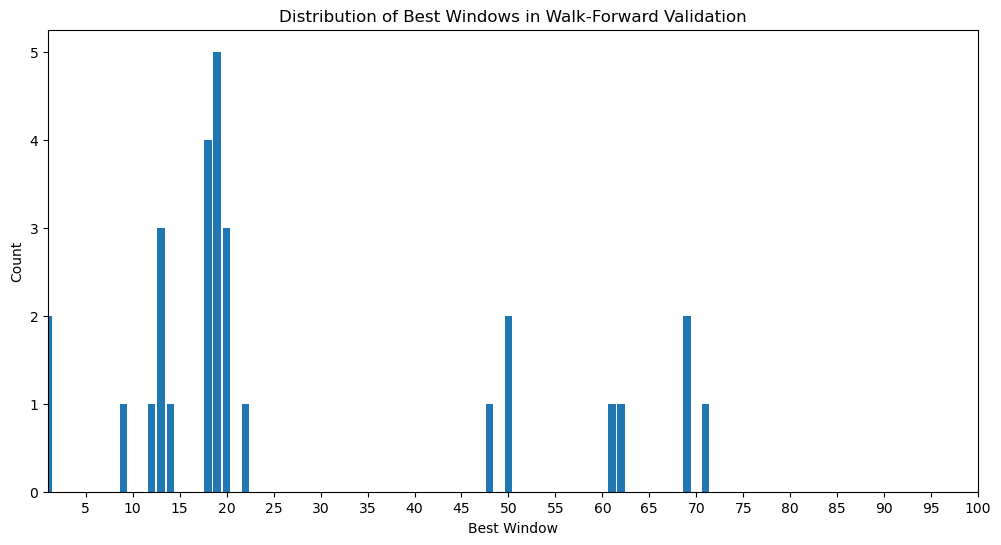

In [31]:
import matplotlib.pyplot as plt
import numpy as np

counts = wf['best_window'].value_counts().sort_index()
x = np.arange(1, 101)
y = [counts.get(i, 0) for i in x]

plt.figure(figsize=(12,6))
plt.bar(x, y)
plt.xlabel('Best Window')
plt.ylabel('Count')
plt.title('Distribution of Best Windows in Walk-Forward Validation')
plt.xticks(np.arange(0, 101, 5))
plt.xlim(1, 100)
plt.show()



There is some obvious clustering here (9-22), but I want to know if some windows generate true momentum signals. So, I want to build my ensemble of windows mathematically by ranking each window based on OOS performance.

In [32]:
def evaluate_windows(df, windows, **wf_params):
    all_results = []

    for w in windows:
        wf = walk_forward_validation(
            df,
            windows=[w],  # only test this one window
            **wf_params
        )
        wf['window'] = w
        all_results.append(wf)

    return pd.concat(all_results, ignore_index=True)


In [33]:
windows = list[int](range(1, 101))

wf_all = evaluate_windows(
    df,
    windows=windows,
    train_days=365,
    test_days=90,
    vol_window=24,
    k=1.0,
    z_threshold=0.5,
    long_only=False
)

In [34]:
agg = wf_all.groupby('window').agg(
    mean_sharpe=('sharpe', 'mean'),
    median_sharpe=('sharpe', 'median'),
    std_sharpe=('sharpe', 'std'),
    mean_return=('total_return', 'mean'),
    worst_drawdown=('max_drawdown', 'min')
).reset_index()

agg['std_sharpe'] = agg['std_sharpe'].fillna(999)
agg = agg.fillna(-999)


In [35]:
agg['rank_mean_sharpe'] = agg['mean_sharpe'].rank()
agg['rank_median_sharpe'] = agg['median_sharpe'].rank()
agg['rank_mean_return'] = agg['mean_return'].rank()

# negative drawdown → invert sign first
agg['rank_worst_drawdown'] = (-agg['worst_drawdown']).rank()

# penalize unstable windows
agg['rank_stability'] = (-agg['std_sharpe']).rank()


In [36]:
agg['score'] = (
    0.50 * agg['rank_mean_sharpe'] +
    0.20 * agg['rank_median_sharpe'] +
    0.20 * agg['rank_mean_return'] +
    0.10 * agg['rank_worst_drawdown'] +
    0.10 * agg['rank_stability']
)

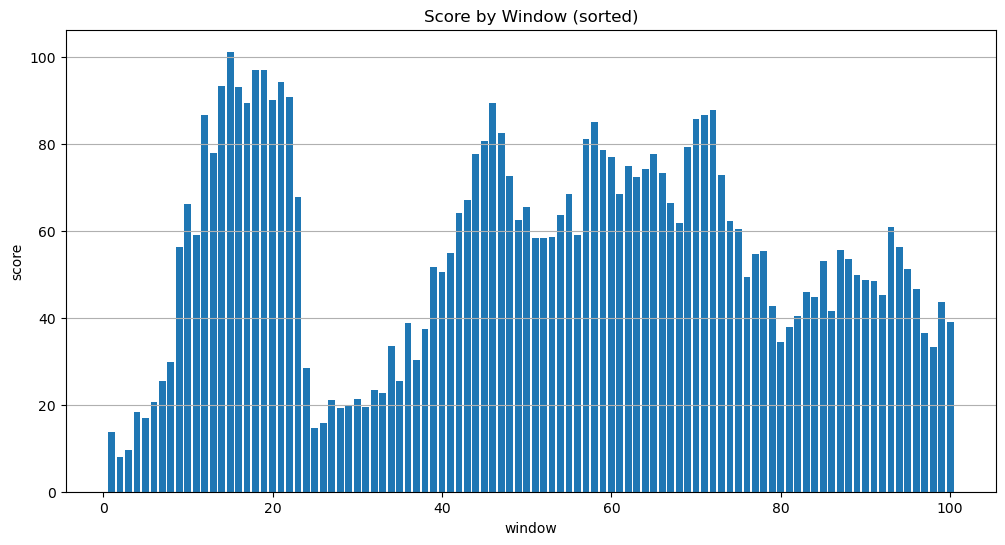

In [37]:
agg_sorted = agg.sort_values('score', ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(agg_sorted['window'], agg_sorted['score'])
plt.xlabel('window')
plt.ylabel('score')
plt.title('Score by Window (sorted)')
plt.grid(axis='y')
plt.show()



There is a meaningful cluster between 12 to 22. Let us take the top 5 best windows from our agg_sorted dataframe

In [38]:
sensitive_window = list(agg_sorted['window'][:3])
stable_window = list(agg_sorted['window'][:5])

print(sensitive_window)
print(stable_window)

[15, 19, 18]
[15, 19, 18, 21, 14]


## Window Classification

The smaller window is called **"sensitive"** because shorter lookback periods typically make the momentum signal more reactive to recent price changes, increasing responsiveness but also the risk of noise and overfitting.

In contrast, the larger (top 5) windows are considered **"stable"** because using a longer lookback period smooths out short-term fluctuations, making the signal slower but more robust and less sensitive to random market moves. However, they might not capture the alpha in time.


We will build ensemble signals 

In [39]:
def build_ensemble_signal(df, windows, vol_window=24):
    sigs = []
    eps = 1e-8  # Small value to prevent division by zero
    for w in windows:
        mom = df['log_return'].rolling(w).sum()
        vol = df['log_return'].rolling(vol_window).std()
        z = mom / (vol + eps)
        sigs.append(z)

    # average all signals → ensemble trend strength
    return pd.concat(sigs, axis=1).mean(axis=1)

In [40]:
def build_ensemble_positions(df, z_col, k=1.0, z_threshold=0.5, long_only=False):
    z = df[z_col]

    # signal → bounded exposure
    pos_raw = np.tanh(k * z)

    # thresholding to avoid chop
    pos = np.where(abs(z) < z_threshold, 0.0, pos_raw)

    if long_only:
        pos = np.clip(pos, 0, 1)

    return pos

In [41]:
def run_ensemble_backtest(
    df,
    windows,
    vol_window=24,
    k=1.0,
    z_threshold=0.5,
    long_only=False
):
    data = df.copy()

    # 1) Build ensemble z-score
    data['z_ensemble'] = build_ensemble_signal(data, windows, vol_window=vol_window)

    # 2) Build positions
    data['position'] = build_ensemble_positions(
        data, 
        'z_ensemble',
        k=k,
        z_threshold=z_threshold,
        long_only=long_only
    )

    # 3) Apply position with 1-bar lag
    data['position_shifted'] = data['position'].shift(1).fillna(0)

    # 4) Strategy returns
    data['strat_return'] = data['position_shifted'] * data['log_return']

    # drop warmup
    data = data.dropna().copy()

    # 5) Equity curve
    data['equity'] = np.exp(data['strat_return'].cumsum())

    # 6) Drawdown
    data['running_max'] = data['equity'].cummax()
    data['drawdown'] = data['equity'] / data['running_max'] - 1
    max_dd = data['drawdown'].min()

    # 7) Sharpe metrics
    bars_per_year = 24 * 365
    mu = data['strat_return'].mean()
    sigma = data['strat_return'].std()

    sharpe = np.nan if sigma == 0 else (mu / sigma) * np.sqrt(bars_per_year)
    volatility = sigma * np.sqrt(bars_per_year)
    total_return = np.exp(data['strat_return'].sum()) - 1

    return data, {
        'windows': windows,
        'total_return': total_return,
        'sharpe': sharpe,
        'volatility': volatility,
        'max_drawdown': max_dd
    }

In [42]:
def walk_forward_ensemble(df, ensemble_windows, **params):
    results = []

    train_len = params['train_days'] * 24
    test_len = params['test_days'] * 24

    start = 0
    end = len(df)

    while start + train_len + test_len < end:
        train = df.iloc[start : start + train_len]
        test = df.iloc[start + train_len : start + train_len + test_len]

        # no window selection, fixed ensemble
        _, test_stats = run_ensemble_backtest(
            test,
            ensemble_windows,
            vol_window=params.get('vol_window', 24),
            k=params.get('k', 1.0),
            z_threshold=params.get('z_threshold', 0.5),
            long_only=params.get('long_only', False)
        )

        test_stats['train_range'] = f"{train.index[0]} → {train.index[-1]}"
        test_stats['test_range'] = f"{test.index[0]} → {test.index[-1]}"

        results.append(test_stats)

        start += test_len

    return pd.DataFrame(results)


In [43]:
# 5 day window
wf_ensemble_stable = walk_forward_ensemble(
    df,
    ensemble_windows=stable_window,
    train_days=365,
    test_days=90,
    vol_window=24,
    k=1.0,
    z_threshold=0.5,
    long_only=False
)


# 3 day window
wf_ensemble_sensitive = walk_forward_ensemble(
    df,
    ensemble_windows=sensitive_window,
    train_days=365,
    test_days=90,
    vol_window=24,
    k=1.0,
    z_threshold=0.5,
    long_only=False
)

from IPython.display import display, Markdown

display(Markdown("### Walk-forward Ensemble (Stable) Summary"))
display(wf_ensemble_stable.describe().style.format("{:.6f}"))

display(Markdown("### Walk-forward Ensemble (Sensitive) Summary"))
display(wf_ensemble_sensitive.describe().style.format("{:.6f}"))


### Walk-forward Ensemble (Stable) Summary

,total_return,sharpe,volatility,max_drawdown
count,29.000000,29.000000,29.000000,29.000000
mean,0.348691,1.499424,0.720137,-0.227395
std,0.316571,1.106439,0.234662,0.077738
min,-0.090078,-0.645832,0.346113,-0.399210
25%,0.123696,0.638526,0.598913,-0.283385
50%,0.237005,1.356287,0.638113,-0.224116
75%,0.543393,2.292491,0.811742,-0.156783
max,1.094960,3.548443,1.264081,-0.107417


### Walk-forward Ensemble (Sensitive) Summary

,total_return,sharpe,volatility,max_drawdown
count,29.000000,29.000000,29.000000,29.000000
mean,0.378176,1.590302,0.720549,-0.224145
std,0.351932,1.170759,0.235690,0.072897
min,-0.095438,-0.542058,0.346358,-0.357266
25%,0.117076,0.769345,0.598354,-0.283900
50%,0.250199,1.500048,0.635035,-0.229306
75%,0.592211,2.650823,0.808739,-0.150698
max,1.182695,3.782181,1.265796,-0.103273


## Strategy Selection: 3-Window Ensemble (Sensitive)

I am selecting the **3-Window Ensemble (Sensitive)** approach.

### Reasons for this choice:

- It achieves a higher mean return
- It demonstrates a higher mean Sharpe ratio
- It offers better best-case performance
- It surprisingly delivers a smaller worst-case drawdown
- It is able to adapt more quickly to emerging trends

In [44]:
final_window = sensitive_window

Let's plot the ensemble backtest's equity curve.

In [45]:
def run_ensemble_backtest(
    df,
    windows,
    vol_window=24,
    k=1.0,
    z_threshold=0.5,
    long_only=False
):
    data = df.copy()

    # Build ensemble z-score
    data['z_ensemble'] = build_ensemble_signal(data, windows, vol_window=vol_window)

    # Build positions
    data['position'] = build_ensemble_positions(
        data,
        'z_ensemble',
        k=k,
        z_threshold=z_threshold,
        long_only=long_only
    )

    # lagged position for execution
    data['position_shifted'] = data['position'].shift(1).fillna(0)

    # strategy log returns
    data['strat_return'] = data['position_shifted'] * data['log_return']

    # drop NaN rows consistently
    data = data.dropna().copy()

    # Strategy equity
    data['equity'] = np.exp(data['strat_return'].cumsum())

    # Buy & Hold (aligned to the same trimmed index)
    data['buy_hold'] = np.exp(data['log_return'].cumsum())

    # Normalize both curves to start at 1
    data['equity'] = data['equity'] / data['equity'].iloc[0]
    data['buy_hold'] = data['buy_hold'] / data['buy_hold'].iloc[0]

    return data


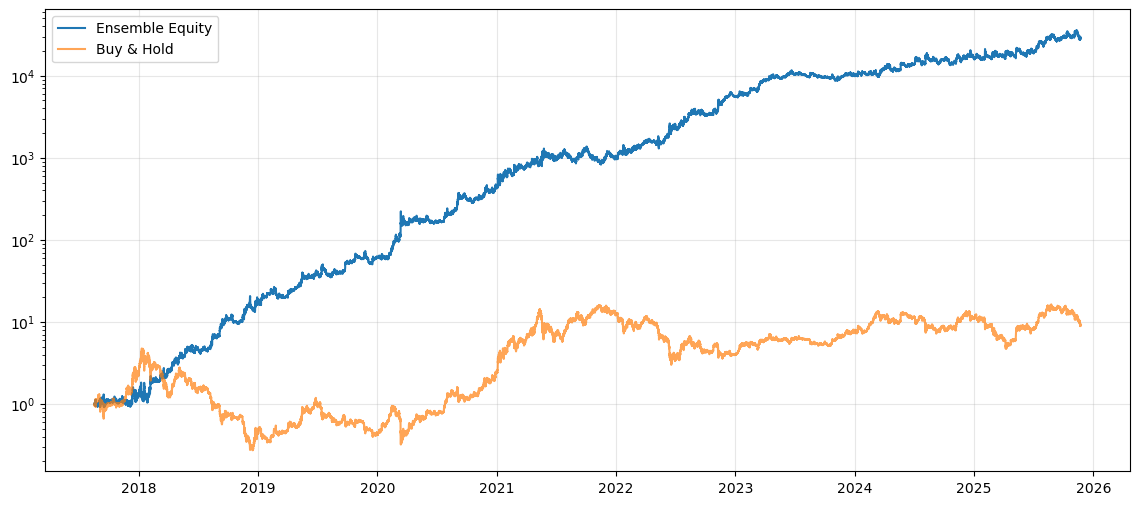

In [46]:
data_ensemble = run_ensemble_backtest(
    df,
    windows=final_window,
    vol_window=24,
    k=1.0,
    z_threshold=0.5,
    long_only=False
)

plt.figure(figsize=(14,6))
plt.plot(data_ensemble.index, data_ensemble['equity'], label='Ensemble Equity')
plt.plot(data_ensemble.index, data_ensemble['buy_hold'], label='Buy & Hold', alpha=0.7)

plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend()
plt.show()



## Note on Results

The blue line represents the theoretical upper bound, as transaction costs are not yet accounted for.

Next, we will incorporate transaction cost modeling into the strategy.


In [47]:
def run_ensemble_backtest_with_cost(
    df,
    windows=[15, 19, 18, 21, 14],
    vol_window=24,
    k=1.0,
    z_threshold=0.5,
    long_only=False,
    fee_rate=0.001,      # 0.10% per trade-side
    slippage=0.0003      # 0.03% per trade-side
):
    data = df.copy()

    # Build ensemble z-score
    data['z_ensemble'] = build_ensemble_signal(data, windows, vol_window=vol_window)

    # Build positions
    data['position'] = build_ensemble_positions(
        data,
        'z_ensemble',
        k=k,
        z_threshold=z_threshold,
        long_only=long_only
    )

    # lagged position for execution
    data['position_shifted'] = data['position'].shift(1).fillna(0)

    # detect trades (entry/exit or switching direction)
    data['trade'] = (data['position_shifted'] != data['position_shifted'].shift(1)).astype(float)

    # total cost per trade-side (fee + slippage)
    cost_per_trade = fee_rate + slippage

    # strategy log returns BEFORE costs
    data['strat_return_raw'] = data['position_shifted'] * data['log_return']

    # subtract costs as log-return penalties
    data['costs'] = data['trade'] * cost_per_trade

    # net strategy log returns
    data['strat_return'] = data['strat_return_raw'] - data['costs']

    # clean NaNs
    data = data.dropna().copy()

    # Strategy equity (net)
    data['equity'] = np.exp(data['strat_return'].cumsum())

    # Buy & Hold (aligned with same rows)
    data['buy_hold'] = np.exp(data['log_return'].cumsum())

    # normalize both curves to start at 1
    data['equity'] /= data['equity'].iloc[0]
    data['buy_hold'] /= data['buy_hold'].iloc[0]

    # Calculate total number of trades (trades are transitions in position)
    total_trades = int(data['trade'].sum())

    return data, total_trades


In [48]:
data_net, total_trades = run_ensemble_backtest_with_cost(
    df,
    windows=final_window,
    vol_window=24,
    k=1.0,
    z_threshold=0.5,
    long_only=False,
    fee_rate=0.001,     # 0.10% fee per trade-side
    slippage=0.0003     # 0.03% slippage
)

In [49]:
print(f"Total trades: {total_trades}")


Total trades: 69351


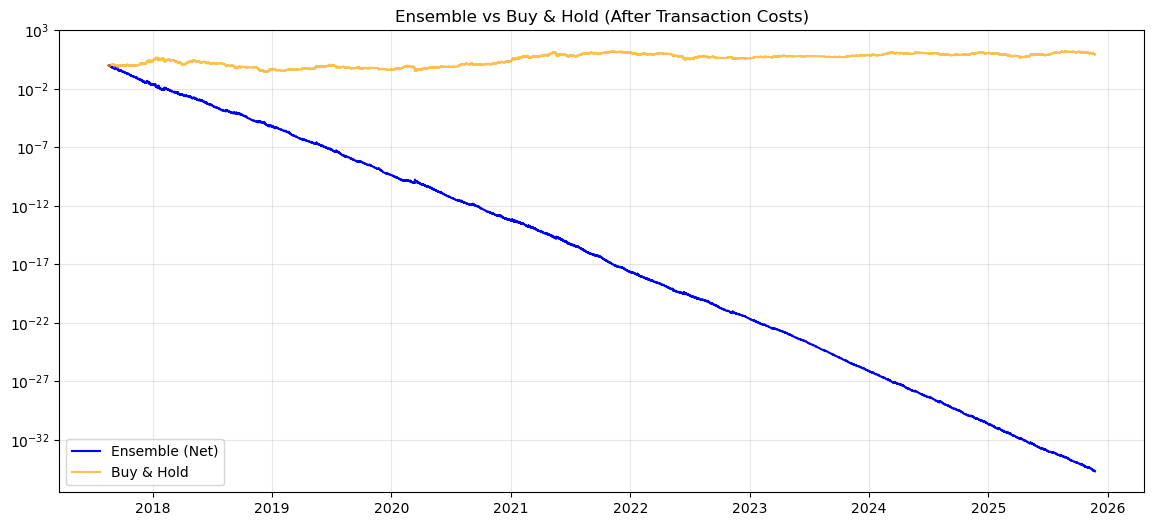

In [50]:
plt.figure(figsize=(14,6))
plt.plot(data_net.index, data_net['equity'], label='Ensemble (Net)', color='blue')
plt.plot(data_net.index, data_net['buy_hold'], label='Buy & Hold', color='orange', alpha=0.7)

plt.yscale('log')
plt.title('Ensemble vs Buy & Hold (After Transaction Costs)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## Reducing Trade Frequency

I need to reduce the number of trades to make this momentum strategy feasible.

### Potential approaches:

- **Trend Regime Filter**: Only trade during trending markets
- **Threshold the signal harder**: Increase `z_threshold` to reduce sensitivity
- **Add a minimum holding period**: Prevent rapid position switching